# X/Y 通道幅度一致性校准（2D 扫描）

测量 Bell-Bloom 磁力仪中 dg_comp CH1 (X) 和 CH2 (Y) 载波通道的幅度偏差，计算修正因子 `XY_AMP_CORRECTION`。

## 原理

在 Bell-Bloom 构型中，CH1 (X) 和 CH2 (Y) 相位差 90°，合成旋转磁场驱动原子进动。当两通道幅度相等时，旋转场为**圆极化**，驱动效率最高，HF2 R 值最大；幅度不等时退化为椭圆极化，R 值下降。

通过 **2D 扫描 CH1 和 CH2 幅度**（限制在 |CH1−CH2| < DIFF_LIMIT 的对角线附近），结合 R 和 θ 信息，找到最优幅度平衡点：

$$ \text{XY\_AMP\_CORRECTION} = \frac{\text{CH1\_最优幅度}}{\text{CH2\_最优幅度}} $$

## 硬件连接

| 信号 | 仪器 | 通道 | 说明 |
|------|------|------|------|
| X 控制 | DG4000 (DG4E234902522) — dg_comp | CH1 | 90kHz 正弦载波 + AM EXT 调制 |
| Y 控制 | DG4000 (DG4E234902522) — dg_comp | CH2 | 90kHz 正弦载波 + AM EXT 调制，X+90° |
| AM DC 控制 | DG4000 (DG4E242401288) — dg_sweep | CH2 | DC 电压 → dg_comp MOD Input |
| Pump 调制 | DG4000 (DG4E222800868) — dg_mod | CH1+CH2 | 100MHz 正弦 + 脉冲门控 (RF 开关) |
| 主磁场 | GS200 | - | 恒流模式，~9.3 mA |
| 光功率 | DG4000 (DG4E231500376) | CH1/CH2 DC | - |
| 温度控制 | TEC103 + DG4000 (dg_temp) | - | 气室温度控制 |
| 信号检测 | HF2 (dev18246) | 信号输入 0 | Demod 0 解调信号 |

## 目录

1. [环境准备](#env) — 库导入、参数配置、安全校验、设备连接、初始值设置
2. [Pump 调制与 HF2 校准](#pump) — RF 开关方案，Demod 0 自动相位校准
3. [X/Y AM 调制配置](#xy-setup) — DC 电压控制，载波固定幅度
4. [X/Y 载波相位校准](#phase-cal) — 分通道校相
5. [CH2 幅度扫描](#sweep) — 扫描 CH2 幅度，寻找 R 最大值
6. [结果分析](#analysis) — 抛物线拟合，计算修正因子
7. [安全关闭](#cleanup) — 设备输出关闭、连接断开

<a id='env'></a>
## 1. 环境准备

导入依赖库、加载实验参数与安全限值配置、建立仪器连接、设置初始值（光功率、主磁场、温度）。

In [46]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
# 自动定位项目根目录
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod,
)

# 数据分析库
from scipy.optimize import curve_fit

EXPERIMENT_TYPE = "XY_Channel_Calibration"
PURPOSE = "xy_amplitude_calibration"

print("所有库导入成功")

所有库导入成功


In [61]:
# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========

# ---- AM DC 控制电压（固定中间值）----
# DG4000 MOD Input 满量程 1.3V，外部 AM 线性响应
# 建议: 0~1.0V 之间，太大可能饱和、太小信噪比差
AM_DC_VOLTAGE = 0.5          # AM DC 控制电压 (V)

# ---- X/Y 载波参数（AM 外部调制方案）----
XY_CARRIER_FREQ = 90e3        # X/Y 载波频率 (Hz)，等于 Larmor 频率
XY_CARRIER_AMPLITUDE = 10.0   # 载波幅度中心值 (Vpp)
X_CARRIER_PHASE = 0           # CH1 载波初始相位 (deg)，校相后确定
Y_CARRIER_PHASE = 90          # CH2 载波初始相位 (deg)，校相后确定
XY_AM_DEPTH = 100             # AM 调制深度 (%)

# ---- 2D 扫描参数 ----
# 同时扫描 CH1 和 CH2 幅度，只测量 |CH1-CH2| < DIFF_LIMIT 的点
AMPLITUDE_MIN = 2    # 扫描幅度最小值 (Vpp)
AMPLITUDE_MAX = 10   # 扫描幅度最大值 (Vpp)
AMPLITUDE_POINTS = 81                     # 每轴扫描点数
AMPLITUDE_DIFF_LIMIT = 2                # |CH1-CH2| 最大允许偏差 (Vpp)
SETTLE_TIME = 0.5                         # 每点等待稳定时间 (s)
FIT_BOUNDARY_MARGIN = 0.1                 # 拟合剔除边界余量 (Vpp)

# ---- Pump 调制参数 ----
PUMP_MOD_FREQ = 90e3
PUMP_MOD_AMPLITUDE = 0.18
PUMP_MOD_DUTY = 5
RF_GATE_AMPLITUDE = 5.0
RF_GATE_OFFSET = 2.5

# ---- HF2 解调配置 ----
HF2_DEMOD_IDX = 0
HF2_OSC_FREQ = 90e3
HF2_SIGNAL_RANGE = 2.0
HF2_DEMOD_ORDER = 8
HF2_DEMOD_TC = 0.000692
HF2_DEMOD_RATE = 100000

# ---- 固定参数 ----
FIXED_PARAMS = {
    "Pump_laser_power": 0.1,         "Probe_laser_power": 0.1,
    "temperature": 100,              "Temp_Switch": 5.0,
    "main_magnetic_field": 9.305,
}

# ---- 运行目录命名 ----
RUN_TAG = "xy_calib2d"

print("配置已加载")
print(f"  2D 扫描: CH1/CH2 ∈ [{AMPLITUDE_MIN:.1f}, {AMPLITUDE_MAX:.1f}] Vpp")
print(f"  |CH1-CH2| < {AMPLITUDE_DIFF_LIMIT} Vpp, 每轴 {AMPLITUDE_POINTS} 点")
print(f"  AM DC = {AM_DC_VOLTAGE} V")

配置已加载
  2D 扫描: CH1/CH2 ∈ [2.0, 10.0] Vpp
  |CH1-CH2| < 2 Vpp, 每轴 81 点
  AM DC = 0.5 V


In [48]:
# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错."""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if lo is not None and hi is not None:
        if value < lo or value > hi:
            raise ValueError(
                f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
            )
    return value

print("安全校验函数已定义")

安全校验函数已定义


In [49]:
devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG4000: X/Y 载波 (dg_comp) ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"dg_comp 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Z 磁场 + AM DC 控制 (dg_sweep) ----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"dg_sweep 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    dg_sweep.setup_dc(0.0, channel=1)
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_output(False, channel=2)
    print(f"  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump 调制 (dg_mod) ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"dg_mod 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 (dg_temp) ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"dg_temp 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- DG4000: 光功率 (dg_laser) ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"dg_laser 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
dg_comp 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
dg_sweep 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF
dg_mod 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
dg_temp 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
dg_laser 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部

所有设备连接完成，共 8 个设备


In [50]:
hfi = devices["hf2"]
tec = devices["tec"]
gs = devices["gs200"]
dg_laser = devices["dg_laser"]
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
dg_mod = devices["dg_mod"]
dg_temp = devices["dg_temp"]

# ---- 1. Pump 光功率 ----
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
print(f"Pump 光功率: {FIXED_PARAMS['Pump_laser_power']} V DC")

# ---- 2. Probe 光功率 ----
validate_safety_limit("Probe_laser_power", FIXED_PARAMS["Probe_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Probe_laser_power"], channel=2)
print(f"Probe 光功率: {FIXED_PARAMS['Probe_laser_power']} V DC")

# ---- 3. 主磁场 ----
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["main_magnetic_field"])
gs.set_current(FIXED_PARAMS["main_magnetic_field"] / 1000.0)
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA")

# ---- 4. 温度开关 (ON) ----
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# ---- 5. 温度控制 ----
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    try:
        t2 = tec.get_temperature(channel=1)
        if abs(t2 - FIXED_PARAMS['temperature']) < 1:
            print(f"温度已稳定: {t:.2f} °C")
            break
    except:
        pass

# ---- 6. Z 磁场关闭 & AM DC 初始 0V ----
dg_sweep.setup_dc(0.0, channel=1)
dg_sweep.set_output(False, channel=1)
dg_sweep.setup_dc(0.0, channel=2)
dg_sweep.set_output(False, channel=2)
print("Z 磁场: OFF; AM DC: 初始 0V, OFF")

# ---- 创建运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 保存实验配置到运行目录 ----
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "am_dc_voltage_V": AM_DC_VOLTAGE,
    "xy_carrier_am": {
        "XY_CARRIER_FREQ_Hz": XY_CARRIER_FREQ,
        "XY_CARRIER_AMPLITUDE_Vpp": XY_CARRIER_AMPLITUDE,
        "XY_AM_DEPTH_pct": XY_AM_DEPTH,
        "X_CARRIER_PHASE_deg": X_CARRIER_PHASE,
        "Y_CARRIER_PHASE_deg": Y_CARRIER_PHASE,
    },
    "scan_params": {
        "AMPLITUDE_MIN_Vpp": AMPLITUDE_MIN,
        "AMPLITUDE_MAX_Vpp": AMPLITUDE_MAX,
        "AMPLITUDE_POINTS": AMPLITUDE_POINTS,
        "AMPLITUDE_DIFF_LIMIT_Vpp": AMPLITUDE_DIFF_LIMIT,
        "SETTLE_TIME_s": SETTLE_TIME,
    },
    "fixed_params": FIXED_PARAMS,
    "pump_modulation": {
        "pump_mod_freq_Hz": PUMP_MOD_FREQ,
        "pump_mod_amplitude_V": PUMP_MOD_AMPLITUDE,
        "pump_mod_duty_pct": PUMP_MOD_DUTY,
    },
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "osc_freq_Hz": HF2_OSC_FREQ,
        "signal_range_V": HF2_SIGNAL_RANGE,
        "demod_rate_Sa_s": HF2_DEMOD_RATE,
        "demod_TC_s": HF2_DEMOD_TC,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光功率: 0.1 V DC
Probe 光功率: 0.1 V DC
主磁场: 9.305 mA
温度开关: ON (5.0 V)
温度设定: 100 °C, 当前: 100.0 °C
等待温度稳定...
  当前温度: 100.00 °C
温度已稳定: 100.00 °C
Z 磁场: OFF; AM DC: 初始 0V, OFF
运行目录: d:\Code\exp_agent\data\XY_Channel_Calibration\0521_1624_xy_calib2d
实验配置已保存: d:\Code\exp_agent\data\XY_Channel_Calibration\0521_1624_xy_calib2d\experiment_config.yaml

初始值设置完成


<a id='pump'></a>
## 2. Pump 调制与 HF2 相位校准

配置 RF 开关方案的 Pump 调制，完成 HF2 Demod 0 自动相位校准。

In [53]:
# ---- RF 开关方案（Pump 调制）----
print("CH1: 100MHz 连续正弦波...")
dg_mod.setup_sine(freq=100e6, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, phase=0.0, channel=1)
print(f"  100MHz, {PUMP_MOD_AMPLITUDE*1000:.0f} mVpp → RF 开关 IN")

pulse_width = (PUMP_MOD_DUTY / 100.0) / PUMP_MOD_FREQ
print(f"\nCH2: {PUMP_MOD_FREQ/1e3:.0f} kHz 脉冲门控, 脉宽 {pulse_width*1e6:.2f} μs")
dg_mod.setup_pulse(freq=PUMP_MOD_FREQ, amplitude=RF_GATE_AMPLITUDE,
                   offset=RF_GATE_OFFSET, width=pulse_width, channel=2)
dg_mod.set_output(True, channel=1)
dg_mod.set_output(True, channel=2)
dg_mod.set_sync_state(True, channel=2)
print("  dg_mod 输出: CH1(100MHz) ON, CH2(脉冲) ON, SYNC ON")

# ---- HF2 Demod 0 相位校准 ----
print("\n关闭温度开关（相位校准前）...")
dg_temp.set_output(False, channel=2)
dg_comp.set_output(False, channel=1)
dg_comp.set_output(False, channel=2)

sig_in_cfg = SignalInputConfig(
    input_index=0, range=HF2_SIGNAL_RANGE,
    ac_coupling=True, diff=False, impedance=50,
)
demod.configure_signal_input(hfi, sig_in_cfg)
print(f"信号输入: {HF2_SIGNAL_RANGE} V, AC coupled")

osc_cfg = OscillatorConfig(osc_index=0, frequency=HF2_OSC_FREQ)
demod.configure_oscillator(hfi, osc_cfg)
print(f"振荡器: {HF2_OSC_FREQ/1e3:.0f} kHz")

demod_cfg = DemodulatorConfig(
    demod_index=0, enable=True, rate=HF2_DEMOD_RATE,
    input_channel=0, osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER, phase=0.0,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"解调器 0: rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1000:.3f} ms")

calibrated_phase = demod.auto_calibrate_phase(
    hfi, demod_idx=0, tolerance_deg=1.0, max_attempts=5, settle_time=0.2
)
print(f"相位校准完成: {calibrated_phase:.2f}°")

sample = demod.read_demod_sample(hfi, demod_idx=0)
print(f"校准后样本: R={sample['r']:.6f}, X={sample['x']:.6f}, Y={sample['y']:.6f}")

dg_temp.set_output(True, channel=2)
print("温度开关已恢复")

CH1: 100MHz 连续正弦波...
  100MHz, 180 mVpp → RF 开关 IN

CH2: 90 kHz 脉冲门控, 脉宽 0.56 μs
  dg_mod 输出: CH1(100MHz) ON, CH2(脉冲) ON, SYNC ON

关闭温度开关（相位校准前）...
信号输入: 2.0 V, AC coupled
振荡器: 90 kHz
解调器 0: rate=115132 Sa/s, TC=0.692 ms
相位校准完成: 136.71°
校准后样本: R=0.339979, X=0.339979, Y=0.000092
温度开关已恢复


<a id='xy-setup'></a>
## 3. X/Y AM 调制配置

配置 dg_comp CH1/CH2 为 AM 外部调制模式，载波幅度固定。dg_sweep CH2 输出 DC 电压控制有效场强。

In [54]:
# ---- 设置 dg_sweep CH2 DC 电压 ----
print("\n设置 dg_sweep CH2 DC 电压...")
dg_sweep.setup_dc(AM_DC_VOLTAGE, channel=2)
dg_sweep.set_output(True, channel=2)
print(f"AM DC 电压: {AM_DC_VOLTAGE} V")

# ---- 配置 dg_comp CH1/CH2 AM 外部调制 ----
print("\n配置 X/Y AM 调制载波...")

# CH1: X 载波（固定参考幅度）
dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=XY_CARRIER_AMPLITUDE,
                   phase=0.0, channel=1)
dg_comp.set_mod_type("AM", channel=1)
dg_comp.set_mod_am_source("EXT", channel=1)
dg_comp.set_mod_am_depth(XY_AM_DEPTH, channel=1)
dg_comp.set_mod_state(True, channel=1)
print(f"CH1: X 载波 {XY_CARRIER_FREQ/1000:.0f} kHz, {XY_CARRIER_AMPLITUDE} Vpp (参考)")

# CH2: Y 载波（待校准幅度）
dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=XY_CARRIER_AMPLITUDE,
                   phase=0.0, channel=2)
dg_comp.set_mod_type("AM", channel=2)
dg_comp.set_mod_am_source("EXT", channel=2)
dg_comp.set_mod_am_depth(XY_AM_DEPTH, channel=2)
dg_comp.set_mod_state(True, channel=2)
print(f"CH2: Y 载波 {XY_CARRIER_FREQ/1000:.0f} kHz, {XY_CARRIER_AMPLITUDE} Vpp (待校准)")

print("\n硬件连接: dg_sweep CH2 → BNC → dg_comp MOD Input")
print(f"DC={AM_DC_VOLTAGE}V → AM 输出={AM_DC_VOLTAGE/1.3*100:.0f}% 载波幅度")


设置 dg_sweep CH2 DC 电压...
AM DC 电压: 0.5 V

配置 X/Y AM 调制载波...
CH1: X 载波 90 kHz, 10.0 Vpp (参考)
CH2: Y 载波 90 kHz, 10.0 Vpp (待校准)

硬件连接: dg_sweep CH2 → BNC → dg_comp MOD Input
DC=0.5V → AM 输出=38% 载波幅度


<a id='phase-cal'></a>
## 4. X/Y 载波相位校准

分通道独立校相，确保 CH1 和 CH2 的载波相位正交（90° 差）。

In [55]:
import math

print("=" * 60)
print("分通道校相：X/Y 载波相位校准")
print("=" * 60)

# 关闭温控
dg_temp.set_output(False, channel=2)
print("温度开关: OFF")

# ---- 校准 CH1 相位 ----
print("\n校准 CH1 相位...")
dg_comp.set_output(False, channel=2)
dg_comp.set_output(True, channel=1)
time.sleep(0.5)

for iteration in range(5):
    sample = demod.read_demod_sample(hfi, demod_idx=0)
    phase_offset = math.degrees(sample["theta"])
    print(f"  CH1 迭代 {iteration+1}: theta = {phase_offset:.2f}°")
    if abs(phase_offset) < 0.3:
        print(f"  CH1 相位已收敛 (<0.3°)")
        break
    X_CARRIER_PHASE = (X_CARRIER_PHASE - phase_offset) % 360
    dg_comp.set_phase_adjust(X_CARRIER_PHASE, channel=1)
    time.sleep(0.5)
print(f"  CH1 最终载波相位 = {X_CARRIER_PHASE:.2f}°")

# ---- 校准 CH2 相位 ----
print("\n校准 CH2 相位...")
dg_comp.set_output(True, channel=2)
dg_comp.set_phase_adjust(Y_CARRIER_PHASE, channel=2)
time.sleep(0.3)

for iteration in range(15):
    sample = demod.read_demod_sample(hfi, demod_idx=0)
    phase_offset = math.degrees(sample["theta"])
    print(f"  CH2 迭代 {iteration+1}: theta = {phase_offset:.2f}°")
    if abs(phase_offset) < 0.3:
        print(f"  CH2 相位已收敛 (<0.3°)")
        break
    Y_CARRIER_PHASE = (Y_CARRIER_PHASE - phase_offset) % 360
    dg_comp.set_phase_adjust(Y_CARRIER_PHASE, channel=2)
    time.sleep(0.5)

print(f"  CH2 最终载波相位 = {Y_CARRIER_PHASE:.2f}°")
print(f"  实际相位差 = {(Y_CARRIER_PHASE - X_CARRIER_PHASE) % 360:.2f}°")

dg_temp.set_output(True, channel=2)
print("\n温度开关: ON (已恢复)")
print(f"✅ 分通道校相完成")

分通道校相：X/Y 载波相位校准
温度开关: OFF

校准 CH1 相位...
  CH1 迭代 1: theta = -1.92°
  CH1 迭代 2: theta = -0.00°
  CH1 相位已收敛 (<0.3°)
  CH1 最终载波相位 = 1.92°

校准 CH2 相位...
  CH2 迭代 1: theta = 4.48°
  CH2 迭代 2: theta = 1.90°
  CH2 迭代 3: theta = 0.70°
  CH2 迭代 4: theta = 0.25°
  CH2 相位已收敛 (<0.3°)
  CH2 最终载波相位 = 82.92°
  实际相位差 = 81.01°

温度开关: ON (已恢复)
✅ 分通道校相完成


<a id='sweep'></a>
## 5. CH1/CH2 2D 幅度扫描

同时对 CH1 和 CH2 载波幅度进行 2D 网格扫描，只测量 |CH1−CH2| < AMPLITUDE_DIFF_LIMIT 的点（对角线附近）。记录每点的 R 和 θ 用于后续分析。

In [56]:
# ============================================================
# CH1/CH2 2D 幅度扫描：对角线附近网格
# [经验] 扫描 |CH1-CH2| < DIFF_LIMIT 的区域，R 最大处对应圆极化
# [经验] θ 变化反映 CH1/CH2 幅度比偏离平衡的程度
# ============================================================
print("=" * 60)
print("CH1/CH2 2D 幅度扫描校准")
print("=" * 60)
print(f"扫描范围: {AMPLITUDE_MIN} ~ {AMPLITUDE_MAX} Vpp")
print(f"网格: {AMPLITUDE_POINTS}×{AMPLITUDE_POINTS}")
print(f"|CH1-CH2| < {AMPLITUDE_DIFF_LIMIT} Vpp")
print(f"AM DC 电压: {AM_DC_VOLTAGE} V")
print()

# 生成 2D 网格
ch1_vals = np.linspace(
    AMPLITUDE_MIN,
    AMPLITUDE_MAX,
    AMPLITUDE_POINTS,
)
ch2_vals = np.linspace(
    AMPLITUDE_MIN,
    AMPLITUDE_MAX,
    AMPLITUDE_POINTS,
)

# 预筛选：只测量 |CH1-CH2| < DIFF_LIMIT 的点
scan_points = []
for a1 in ch1_vals:
    for a2 in ch2_vals:
        if abs(a1 - a2) <= AMPLITUDE_DIFF_LIMIT:
            scan_points.append((a1, a2))

total_points = len(scan_points)
print(f"总扫描点数: {total_points} (满网格 {AMPLITUDE_POINTS**2} 点)")
print(f"预计耗时: ~{total_points * (SETTLE_TIME + 1.0):.0f}s")
print()

# 确保双通道输出打开
dg_comp.set_output(True, channel=1)
dg_comp.set_output(True, channel=2)

# 数据容器
ch1_list, ch2_list = [], []
r_list, theta_list = [], []
x_list, y_list = [], []

t_start = time.time()

# try/finally 确保异常时恢复温度开关
try:
    for idx, (a1, a2) in enumerate(scan_points):
        # 设置 CH1 和 CH2 幅度
        dg_comp.set_amplitude(a1, channel=1)
        dg_comp.set_amplitude(a2, channel=2)
        time.sleep(SETTLE_TIME)

        # 关闭温控消除干扰
        dg_temp.set_output(False, channel=2)
        time.sleep(0.2)

        # 读取 HF2 采样
        sample = demod.read_demod_sample(hfi, demod_idx=0)
        r_val = sample["r"]
        theta_val = float(np.degrees(sample["theta"]))
        x_val = sample["x"]
        y_val = sample["y"]

        # 保存
        ch1_list.append(a1)
        ch2_list.append(a2)
        r_list.append(r_val)
        theta_list.append(theta_val)
        x_list.append(x_val)
        y_list.append(y_val)

        # 恢复温控
        dg_temp.set_output(True, channel=2)

        if (idx + 1) % 20 == 0 or idx == 0:
            print(f"  [{idx+1}/{total_points}] CH1={a1:.3f} CH2={a2:.3f} "
                  f"R={r_val:.6f} θ={theta_val:+.1f}°")

except Exception as e:
    print(f"\n扫描出错: {e}")
    dg_temp.set_output(True, channel=2)
    raise

finally:
    dg_temp.set_output(True, channel=2)

elapsed = time.time() - t_start
avg_time = elapsed / total_points if total_points > 0 else 0
print(f"\n扫描完成! 共 {total_points} 点, 用时 {elapsed:.0f}s ({avg_time:.2f}s/点)")

# 保存原始数据
ch1_arr = np.array(ch1_list)
ch2_arr = np.array(ch2_list)
r_arr = np.array(r_list)
theta_arr = np.array(theta_list)
x_arr = np.array(x_list)
y_arr = np.array(y_list)

np.savez(raw_dir / "xy_2d_scan.npz",
         ch1=ch1_arr, ch2=ch2_arr,
         r=r_arr, theta=theta_arr,
         x=x_arr, y=y_arr)

CH1/CH2 2D 幅度扫描校准
扫描范围: 2 ~ 10 Vpp
网格: 81×81
|CH1-CH2| < 2 Vpp
AM DC 电压: 0.5 V

总扫描点数: 2871 (满网格 6561 点)
预计耗时: ~4306s

  [1/2871] CH1=2.000 CH2=2.000 R=0.399757 θ=+0.4°
  [20/2871] CH1=2.000 CH2=3.900 R=0.400327 θ=+0.1°
  [40/2871] CH1=2.100 CH2=3.800 R=0.400841 θ=+0.1°
  [60/2871] CH1=2.200 CH2=3.600 R=0.399951 θ=+0.1°
  [80/2871] CH1=2.300 CH2=3.300 R=0.398701 θ=+0.3°
  [100/2871] CH1=2.400 CH2=3.000 R=0.399682 θ=+0.3°
  [120/2871] CH1=2.500 CH2=2.600 R=0.398373 θ=+0.4°
  [140/2871] CH1=2.600 CH2=2.000 R=0.397275 θ=+0.5°
  [160/2871] CH1=2.600 CH2=4.000 R=0.402367 θ=+0.1°
  [180/2871] CH1=2.700 CH2=3.300 R=0.399953 θ=+0.3°
  [200/2871] CH1=2.800 CH2=2.500 R=0.398864 θ=+0.5°
  [220/2871] CH1=2.800 CH2=4.500 R=0.400409 θ=+0.1°
  [240/2871] CH1=2.900 CH2=3.700 R=0.401415 θ=+0.1°
  [260/2871] CH1=3.000 CH2=2.800 R=0.398907 θ=+0.5°
  [280/2871] CH1=3.000 CH2=4.800 R=0.399831 θ=+0.1°
  [300/2871] CH1=3.100 CH2=3.700 R=0.401723 θ=+0.1°
  [320/2871] CH1=3.200 CH2=2.500 R=0.398414 θ=+0.5°
  [

<a id='analysis'></a>
## 6. 结果分析

R 与 θ 在 2D 幅度平面上的响应。R 最大值对应圆极化平衡点，θ 反映 CH1/CH2 幅度比的偏差方向。

Ridge A (逐 CH1 寻峰): 81 个有效点
Ridge B (逐 CH2 寻峰): 81 个有效点
Ridge A 拟合: 剔除 9 个边界点, 保留 72 个
  Ridge A: CH2 = 1.036806·CH1 + 0.9615, R² = 0.945801
Ridge B 拟合: 剔除 4 个边界点, 保留 77 个
  Ridge B: CH1 = 0.960473·CH2 + -0.2929 → CH2 = 1.041153·CH1 + 0.3049, R² = 0.961588

  Ridge A (per-CH1):  k1 = 1.036806
  Ridge B (per-CH2):  k2 = 1.041153
  综合斜率 k = (k1+k2)/2 = 1.038980
  XY_AMP_CORRECTION = 1/k = 0.962483
  即: CH2 幅度应乘以 0.9625 以匹配 CH1


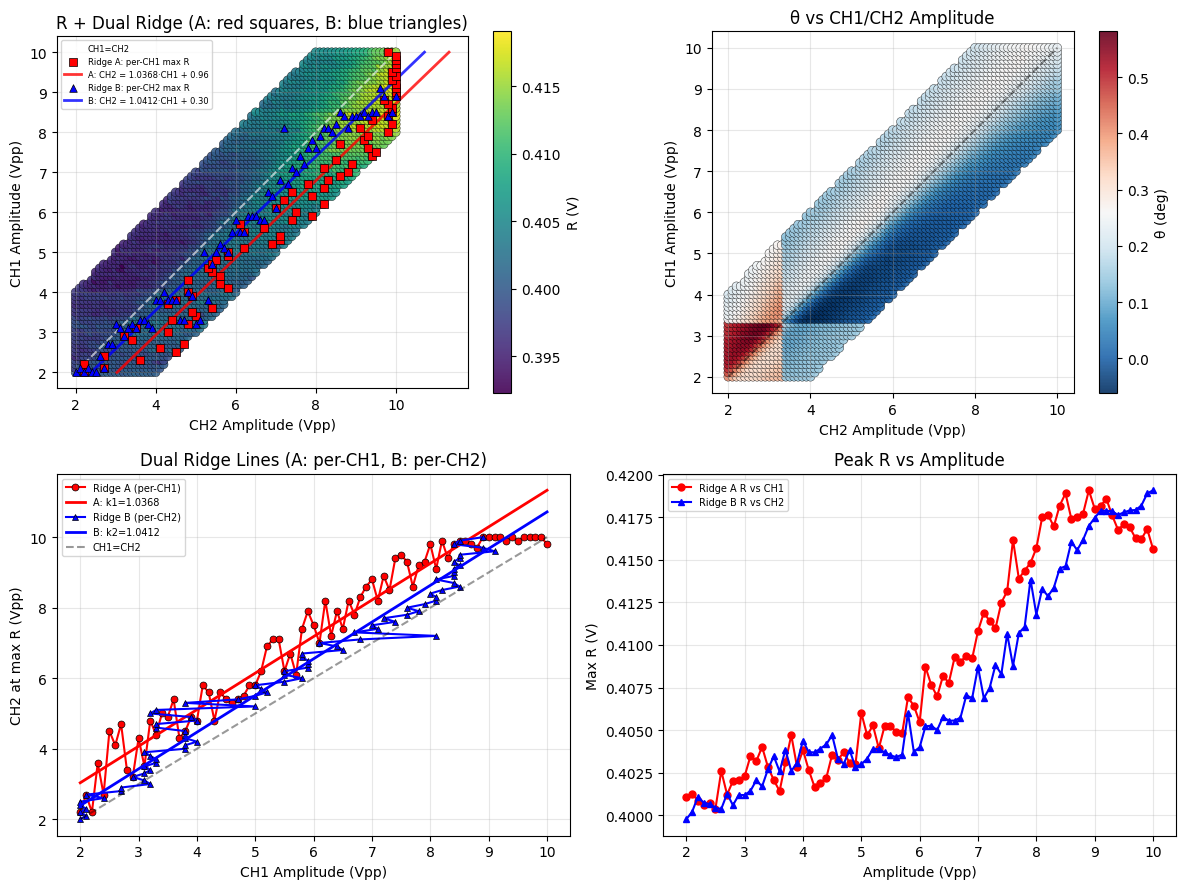


校准结果已保存: d:\Code\exp_agent\data\XY_Channel_Calibration\0521_1624_xy_calib2d\results
  xy_2d_calibration.png — 4 张分析图
  xy_2d_calibration.yaml — 校准参数（含双方向脊线）
  ridge_data.npz — 双方向脊线数据

✅ 校准完成!
   Ridge A (per-CH1): k1 = 1.036806
   Ridge B (per-CH2): k2 = 1.041153
   综合 XY_AMP_CORRECTION = 0.962483
   在主实验中: CH2 幅度应乘以 0.962483


In [65]:
# ============================================================
# 双方向寻峰 + 线性拟合
# Ridge A: 逐 CH1 找 R 最大的 CH2，拟合 CH2 = k1 * CH1 + b1
# Ridge B: 逐 CH2 找 R 最大的 CH1，拟合 CH1 = k2 * CH2 + b2 → CH2 = (CH1 - b2) / k2
# ============================================================

# ---- Step 1A: 对每个 CH1 找 R 最大的 CH2 ----
ch1_unique = sorted(set(ch1_arr))
ch1_ridge_a, ch2_ridge_a, r_ridge_a = [], [], []

for a1 in ch1_unique:
    mask_ch1 = np.abs(ch1_arr - a1) < 1e-6
    if np.sum(mask_ch1) == 0:
        continue
    local_idx = np.argmax(r_arr[mask_ch1])
    ch1_ridge_a.append(a1)
    ch2_ridge_a.append(ch2_arr[mask_ch1][local_idx])
    r_ridge_a.append(r_arr[mask_ch1][local_idx])

ch1_ridge_a = np.array(ch1_ridge_a)
ch2_ridge_a = np.array(ch2_ridge_a)
r_ridge_a = np.array(r_ridge_a)

print(f"Ridge A (逐 CH1 寻峰): {len(ch1_ridge_a)} 个有效点")

# ---- Step 1B: 对每个 CH2 找 R 最大的 CH1 ----
ch2_unique = sorted(set(ch2_arr))
ch1_ridge_b, ch2_ridge_b, r_ridge_b = [], [], []

for a2 in ch2_unique:
    mask_ch2 = np.abs(ch2_arr - a2) < 1e-6
    if np.sum(mask_ch2) == 0:
        continue
    local_idx = np.argmax(r_arr[mask_ch2])
    ch1_ridge_b.append(ch1_arr[mask_ch2][local_idx])
    ch2_ridge_b.append(a2)
    r_ridge_b.append(r_arr[mask_ch2][local_idx])

ch1_ridge_b = np.array(ch1_ridge_b)
ch2_ridge_b = np.array(ch2_ridge_b)
r_ridge_b = np.array(r_ridge_b)

print(f"Ridge B (逐 CH2 寻峰): {len(ch1_ridge_b)} 个有效点")

# ---- Step 2A: 线性拟合 Ridge A: CH2 = k1 * CH1 + b1 ----
BOUNDARY_MARGIN = FIT_BOUNDARY_MARGIN
fit_mask_a = (ch2_ridge_a >= AMPLITUDE_MIN + BOUNDARY_MARGIN) & (ch2_ridge_a <= AMPLITUDE_MAX - BOUNDARY_MARGIN)
ch1_fit_a = ch1_ridge_a[fit_mask_a]
ch2_fit_a = ch2_ridge_a[fit_mask_a]
print(f"Ridge A 拟合: 剔除 {np.sum(~fit_mask_a)} 个边界点, 保留 {len(ch1_fit_a)} 个")

if len(ch1_fit_a) >= 5:
    k1, b1 = np.polyfit(ch1_fit_a, ch2_fit_a, 1)
    ch2_pred_a = k1 * ch1_fit_a + b1
    ss_res_a = np.sum((ch2_fit_a - ch2_pred_a) ** 2)
    ss_tot_a = np.sum((ch2_fit_a - np.mean(ch2_fit_a)) ** 2)
    r_squared_a = 1 - ss_res_a / ss_tot_a if ss_tot_a > 0 else 0.0
    print(f"  Ridge A: CH2 = {k1:.6f}·CH1 + {b1:.4f}, R² = {r_squared_a:.6f}")
else:
    k1 = b1 = 0.0
    r_squared_a = 0.0

# ---- Step 2B: 线性拟合 Ridge B: CH1 = k2 * CH2 + b2 → CH2 = (CH1 - b2) / k2 ----
fit_mask_b = (ch1_ridge_b >= AMPLITUDE_MIN + BOUNDARY_MARGIN) & (ch1_ridge_b <= AMPLITUDE_MAX - BOUNDARY_MARGIN)
ch1_fit_b = ch1_ridge_b[fit_mask_b]
ch2_fit_b = ch2_ridge_b[fit_mask_b]
print(f"Ridge B 拟合: 剔除 {np.sum(~fit_mask_b)} 个边界点, 保留 {len(ch1_fit_b)} 个")

if len(ch1_fit_b) >= 5:
    k2_inv, b2_inv = np.polyfit(ch2_fit_b, ch1_fit_b, 1)  # CH1 = k2_inv * CH2 + b2_inv
    ch1_pred_b = k2_inv * ch2_fit_b + b2_inv
    ss_res_b = np.sum((ch1_fit_b - ch1_pred_b) ** 2)
    ss_tot_b = np.sum((ch1_fit_b - np.mean(ch1_fit_b)) ** 2)
    r_squared_b = 1 - ss_res_b / ss_tot_b if ss_tot_b > 0 else 0.0
    k2 = 1.0 / k2_inv if abs(k2_inv) > 1e-12 else 0.0
    b2 = -b2_inv / k2_inv if abs(k2_inv) > 1e-12 else 0.0
    print(f"  Ridge B: CH1 = {k2_inv:.6f}·CH2 + {b2_inv:.4f} → CH2 = {k2:.6f}·CH1 + {b2:.4f}, R² = {r_squared_b:.6f}")
else:
    k2_inv = k2 = b2_inv = b2 = 0.0
    r_squared_b = 0.0

# ---- 综合修正因子: 两条脊线的平均斜率 ----
k_combined = (k1 + k2) / 2 if abs(k1) > 1e-12 and abs(k2) > 1e-12 else (k1 if abs(k1) > 1e-12 else k2)
if abs(k_combined) > 1e-12:
    XY_AMP_CORRECTION = 1.0 / k_combined
else:
    XY_AMP_CORRECTION = 1.0

print(f"\n{'='*55}")
print(f"  Ridge A (per-CH1):  k1 = {k1:.6f}")
print(f"  Ridge B (per-CH2):  k2 = {k2:.6f}")
print(f"  综合斜率 k = (k1+k2)/2 = {k_combined:.6f}")
print(f"  XY_AMP_CORRECTION = 1/k = {XY_AMP_CORRECTION:.6f}")
print(f"  即: CH2 幅度应乘以 {XY_AMP_CORRECTION:.4f} 以匹配 CH1")
print(f"{'='*55}")

# ============================================================
# 绘图: 2 行 × 2 列 = 4 张图
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ch1_fit_line = np.linspace(AMPLITUDE_MIN, AMPLITUDE_MAX, 2)

# 图 a: R 散点图 + 双方向脊线 + 拟合
ax0 = axes[0, 0]
sc0 = ax0.scatter(ch2_arr, ch1_arr, c=r_arr, s=40, cmap="viridis",
                  edgecolors="k", linewidths=0.3, alpha=0.9)
ax0.plot([AMPLITUDE_MIN, AMPLITUDE_MAX], [AMPLITUDE_MIN, AMPLITUDE_MAX],
         "w--", linewidth=1.5, alpha=0.6, label="CH1=CH2")
# Ridge A (per-CH1): 红色方块
ax0.scatter(ch2_ridge_a, ch1_ridge_a, c="r", s=30, marker="s",
            edgecolors="k", linewidths=0.5, zorder=5, label="Ridge A: per-CH1 max R")
if abs(k1) > 1e-12:
    ax0.plot(k1 * ch1_fit_line + b1, ch1_fit_line, "r-", linewidth=2, alpha=0.8,
             label=f"A: CH2 = {k1:.4f}·CH1 + {b1:.2f}")
# Ridge B (per-CH2): 蓝色三角
ax0.scatter(ch2_ridge_b, ch1_ridge_b, c="b", s=30, marker="^",
            edgecolors="k", linewidths=0.5, zorder=5, label="Ridge B: per-CH2 max R")
if abs(k2) > 1e-12:
    ax0.plot(k2 * ch1_fit_line + b2, ch1_fit_line, "b-", linewidth=2, alpha=0.8,
             label=f"B: CH2 = {k2:.4f}·CH1 + {b2:.2f}")
ax0.set_xlabel("CH2 Amplitude (Vpp)")
ax0.set_ylabel("CH1 Amplitude (Vpp)")
ax0.set_title("R + Dual Ridge (A: red squares, B: blue triangles)")
fig.colorbar(sc0, ax=ax0, label="R (V)")
ax0.legend(fontsize=6)
ax0.set_aspect("equal", adjustable="box")
ax0.grid(True, alpha=0.3)

# 图 b: θ 散点图
ax1 = axes[0, 1]
sc1 = ax1.scatter(ch2_arr, ch1_arr, c=theta_arr, s=40, cmap="RdBu_r",
                  edgecolors="k", linewidths=0.3, alpha=0.9)
ax1.plot([AMPLITUDE_MIN, AMPLITUDE_MAX], [AMPLITUDE_MIN, AMPLITUDE_MAX],
         "k--", linewidth=1.5, alpha=0.4, label="CH1=CH2")
ax1.set_xlabel("CH2 Amplitude (Vpp)")
ax1.set_ylabel("CH1 Amplitude (Vpp)")
ax1.set_title("θ vs CH1/CH2 Amplitude")
fig.colorbar(sc1, ax=ax1, label="θ (deg)")
ax1.set_aspect("equal", adjustable="box")
ax1.grid(True, alpha=0.3)

# 图 c: 双方向脊线散点 + 拟合
ax2 = axes[1, 0]
# Ridge A
ax2.plot(ch1_ridge_a, ch2_ridge_a, "ro-", markersize=5, markerfacecolor="r",
         markeredgecolor="k", markeredgewidth=0.5, label="Ridge A (per-CH1)")
if abs(k1) > 1e-12:
    ax2.plot(ch1_fit_line, k1 * ch1_fit_line + b1, "r-", linewidth=2,
             label=f"A: k1={k1:.4f}")
# Ridge B
ax2.plot(ch1_ridge_b, ch2_ridge_b, "b^-", markersize=5, markerfacecolor="b",
         markeredgecolor="k", markeredgewidth=0.5, label="Ridge B (per-CH2)")
if abs(k2) > 1e-12:
    ax2.plot(ch1_fit_line, k2 * ch1_fit_line + b2, "b-", linewidth=2,
             label=f"B: k2={k2:.4f}")
ax2.plot([AMPLITUDE_MIN, AMPLITUDE_MAX], [AMPLITUDE_MIN, AMPLITUDE_MAX],
         "k--", alpha=0.4, label="CH1=CH2")
ax2.set_xlabel("CH1 Amplitude (Vpp)")
ax2.set_ylabel("CH2 at max R (Vpp)")
ax2.set_title("Dual Ridge Lines (A: per-CH1, B: per-CH2)")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# 图 d: R 最大值 vs CH1 (Ridge A) + R 最大值 vs CH2 (Ridge B)
ax3 = axes[1, 1]
ax3.plot(ch1_ridge_a, r_ridge_a, "ro-", markersize=5, label="Ridge A R vs CH1")
ax3.plot(ch2_ridge_b, r_ridge_b, "b^-", markersize=5, label="Ridge B R vs CH2")
ax3.set_xlabel("Amplitude (Vpp)")
ax3.set_ylabel("Max R (V)")
ax3.set_title("Peak R vs Amplitude")
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(results_dir / "xy_2d_calibration.png", dpi=150)
display(fig)
plt.close(fig)

# ============================================================
# 保存校准结果
# ============================================================
calib_result = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "AM_DC_voltage_V": AM_DC_VOLTAGE,
    "AMPLITUDE_MIN_Vpp": AMPLITUDE_MIN,
    "AMPLITUDE_MAX_Vpp": AMPLITUDE_MAX,
    "AMPLITUDE_POINTS": AMPLITUDE_POINTS,
    "XY_CARRIER_FREQ_Hz": XY_CARRIER_FREQ,
    "X_CARRIER_PHASE_deg": X_CARRIER_PHASE,
    "Y_CARRIER_PHASE_deg": Y_CARRIER_PHASE,
    "ridge_A_per_CH1": {
        "k": float(k1),
        "b": float(b1),
        "R_squared": float(r_squared_a),
        "n_points": len(ch1_fit_a),
    },
    "ridge_B_per_CH2": {
        "CH1_vs_CH2_k": float(k2_inv),
        "CH1_vs_CH2_b": float(b2_inv),
        "CH2_vs_CH1_k": float(k2),
        "CH2_vs_CH1_b": float(b2),
        "R_squared": float(r_squared_b),
        "n_points": len(ch1_fit_b),
    },
    "XY_AMP_CORRECTION": float(XY_AMP_CORRECTION),
    "k_combined": float(k_combined),
}
with open(results_dir / "xy_2d_calibration.yaml", "w", encoding="utf-8") as f:
    yaml.dump(calib_result, f, default_flow_style=False, allow_unicode=True)

# 同时保存脊线数据
np.savez(results_dir / "ridge_data.npz",
         ch1_ridge_a=ch1_ridge_a, ch2_ridge_a=ch2_ridge_a, r_ridge_a=r_ridge_a,
         ch1_ridge_b=ch1_ridge_b, ch2_ridge_b=ch2_ridge_b, r_ridge_b=r_ridge_b,
         k1=k1, b1=b1, k2=k2, b2=b2)

print(f"\n校准结果已保存: {results_dir}")
print(f"  xy_2d_calibration.png — 4 张分析图")
print(f"  xy_2d_calibration.yaml — 校准参数（含双方向脊线）")
print(f"  ridge_data.npz — 双方向脊线数据")
print(f"\n✅ 校准完成!")
print(f"   Ridge A (per-CH1): k1 = {k1:.6f}")
print(f"   Ridge B (per-CH2): k2 = {k2:.6f}")
print(f"   综合 XY_AMP_CORRECTION = {XY_AMP_CORRECTION:.6f}")
print(f"   在主实验中: CH2 幅度应乘以 {XY_AMP_CORRECTION:.6f}")

<a id='cleanup'></a>
## 7. 安全关闭

关闭所有设备输出，断开连接。

In [66]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

# 仅断开连接，不改变任何输出状态
for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
（所有设备输出状态保持当前设置不变）
  gs200 已断开
  dg_comp 已断开
  dg_sweep 已断开
  dg_mod 已断开
  dg_temp 已断开
  tec 已断开
  dg_laser 已断开
  hf2 已断开
所有设备已断开
